In [7]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor # CatBoost için import
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

#-------------------------------------------------------------------------------
# Blok 1: Model Eğitimi, Değerlendirmesi ve Kaydedilmesi (CatBoost ile)
#-------------------------------------------------------------------------------
def train_evaluate_save_model(data_path='veri.csv',
                              target_column='delta_e',
                              min_non_zero_frac_filter=0.01,
                              variance_threshold_filter=1e-5,
                              test_size=0.2,
                              random_state=42,
                              model_filename='catboost_delta_e_model.joblib',
                              scaler_filename='catboost_scaler.joblib',
                              model_features_filename='catboost_model_features.joblib'): # Model özellik dosya adı eklendi
    """
    Veri kümesini yükler, anlamlı özellikleri seçer, CatBoost modelini eğitir,
    değerlendirir ve gerekli tüm dosyaları (model, ölçekleyici, özellik listesi) kaydeder.
    """
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        print(f"HATA: '{data_path}' dosyası bulunamadı. Lütfen dosya yolunu kontrol edin.")
        return None, None, None

    print(f"\n--- Blok 1: Model Eğitimi (CatBoost) ---")
    print(f"Veri '{data_path}' dosyasından yüklendi. Boyut: {df.shape}")

    if target_column not in df.columns:
        print(f"HATA: Hedef sütun '{target_column}' veri setinde bulunamadı.")
        return None, None, None

    X_full = df.drop(target_column, axis=1)
    y = df[target_column]
    print(f"İlk özellik sayısı: {len(X_full.columns)}")

    X_processed = X_full.copy()

    if min_non_zero_frac_filter is not None and 0 < min_non_zero_frac_filter < 1:
        min_non_zero_count = int(min_non_zero_frac_filter * len(df))
        if min_non_zero_count < 1: min_non_zero_count = 1
        cols_before = X_processed.columns.tolist()
        cols_after = [col for col in cols_before if (X_processed[col] != 0).sum() >= min_non_zero_count]
        if not cols_after:
            print(f"HATA: Seyreklik filtresi sonrası özellik kalmadı!")
            return None, None, None
        X_processed = X_processed[cols_after]
        print(f"Seyreklik filtresi: {len(X_processed.columns)} (önce: {len(cols_before)})")
    else:
        print("Seyreklik filtresi atlandı.")

    if variance_threshold_filter is not None and variance_threshold_filter >= 0:
        if X_processed.empty:
            print(f"HATA: Varyans filtresi için özellik yok.")
            return None, None, None
        cols_before = X_processed.columns.tolist()
        selector = VarianceThreshold(threshold=variance_threshold_filter)
        try:
            numeric_cols = X_processed.select_dtypes(include=np.number).columns
            if numeric_cols.empty:
                print(f"HATA: Varyans filtresi için sayısal sütun yok.")
                X = X_processed.copy()
            else:
                selector.fit(X_processed[numeric_cols])
                selected_cols = numeric_cols[selector.get_support()].tolist()
                if not selected_cols:
                    print(f"HATA: Varyans filtresi sonrası sayısal özellik kalmadı!")
                    X = X_processed.copy()
                    if X.empty: return None, None, None
                else:
                    # Sayısal olmayan sütunları da koru (eğer varsa ve istiyorsan)
                    # Bu örnekte sadece sayısal ve filtrelenmiş sütunlar alınıyor.
                    # Eğer diğerlerini de almak istersen, X_processed[selected_cols + non_numeric_cols] gibi birleştirme yapmalısın.
                    X = X_processed[selected_cols] 
                print(f"Varyans filtresi: {len(X.columns)} (önce: {len(cols_before)})")
        except ValueError as e:
            print(f"HATA: Varyans filtresi: {e}. Atlanıyor.")
            X = X_processed.copy()
    else:
        X = X_processed.copy()
        print("Varyans filtresi atlandı.")

    if X.empty:
        print("HATA: Özellik seçimi sonrası özellik kalmadı.")
        return None, None, None

    feature_cols = X.columns.tolist() # Nihai özellik listesi
    print(f"Nihai özellikler ({len(feature_cols)}): {feature_cols if len(feature_cols) < 15 else feature_cols[:5] + ['...'] + feature_cols[-5:] }") # Daha iyi bir gösterim için

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    print(f"Eğitim: {X_train.shape}, Test: {X_test.shape}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("Özellikler ölçeklendirildi.")

    print("CatBoost Regressor modeli eğitiliyor...")
    cat_model = CatBoostRegressor(random_state=random_state, verbose=0, loss_function='RMSE')
    cat_model.fit(X_train_scaled, y_train)
    print("Model eğitimi tamamlandı.")

    y_pred_train = cat_model.predict(X_train_scaled)
    y_pred_test = cat_model.predict(X_test_scaled)
    print("\n--- Model Performansı ---")
    print(f"Eğitim: R²: {r2_score(y_train, y_pred_train):.4f}, RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
    print(f"Test: R²: {r2_score(y_test, y_pred_test):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}, MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")

    # Grafikler (isteğe bağlı)
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred_test, alpha=0.7, edgecolors='k', label='Tahminler')
    min_val, max_val = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='İdeal')
    plt.xlabel("Gerçek ΔE"), plt.ylabel("Tahmini ΔE"), plt.title("Parity Plot (Test Seti - CatBoost)"), plt.legend(), plt.grid(True)
    plt.show()

    residuals = y_test - y_pred_test
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, kde=True, bins=30)
    plt.xlabel("Hata"), plt.ylabel("Frekans"), plt.title("Hata Dağılımı (Test Seti - CatBoost)"), plt.grid(True)
    plt.show()

    if hasattr(cat_model, 'get_feature_importance') and feature_cols:
        importances = cat_model.get_feature_importance()
        fi_df = pd.DataFrame({'feature': feature_cols, 'importance': importances}).sort_values(by='importance', ascending=False).head(20)
        plt.figure(figsize=(10, max(6, len(fi_df) * 0.3)))
        sns.barplot(x='importance', y='feature', data=fi_df)
        plt.title('CatBoost Özellik Önem Sıralaması (Top 20)'), plt.xlabel('Önem'), plt.ylabel('Özellik'), plt.tight_layout()
        plt.show()

    # Kaydetme İşlemleri
    try:
        joblib.dump(cat_model, model_filename)
        print(f"Model '{model_filename}' olarak kaydedildi.")
    except Exception as e:
        print(f"Model kaydedilirken hata: {e}")
        
    try:
        joblib.dump(scaler, scaler_filename)
        print(f"Ölçekleyici '{scaler_filename}' olarak kaydedildi.")
    except Exception as e:
        print(f"Ölçekleyici kaydedilirken hata: {e}")

    try:
        joblib.dump(feature_cols, model_features_filename) # EKLENDİ: Model özelliklerini kaydet
        print(f"Model özellikleri '{model_features_filename}' olarak kaydedildi.")
    except Exception as e:
        print(f"Model özellikleri kaydedilirken hata: {e}")
        
    return cat_model, scaler, feature_cols

In [8]:
def generate_random_composition(elements, min_frac=0.05):
    num_elements = len(elements)
    if num_elements == 0: return {}
    if num_elements * min_frac > 1.0 + 1e-9:
        raise ValueError(f"Kompozisyon oluşturulamaz: {num_elements} element, min_frac={min_frac}")
    if num_elements == 1: return {elements[0]: 1.0}

    composition = {el: min_frac for el in elements}
    remaining_frac = 1.0 - num_elements * min_frac
    if remaining_frac < 0: remaining_frac = 0

    if remaining_frac > 1e-9:
        random_parts = np.random.dirichlet(np.ones(num_elements)) * remaining_frac
        for i, el in enumerate(elements):
            composition[el] += random_parts[i]

    current_sum = sum(composition.values())
    if not np.isclose(current_sum, 1.0) and current_sum > 1e-9:
        for el in composition: composition[el] /= current_sum
    return composition

def find_min_delta_e_random(model, elements_to_vary, all_feature_cols, scaler=None,
                            n_iter=1000, min_frac=0.05, fixed_features=None):
    print(f"\n--- Blok 2: Rastgele ΔE Arama (CatBoost) ---")
    if model is None:
        print("Hata: Model yüklenmemiş.")
        return float('inf'), None

    min_delta_e_val = float('inf')
    best_comp_details = None
    if fixed_features is None: fixed_features = {}

    for i in range(n_iter):
        try:
            current_comp_dict = generate_random_composition(elements_to_vary, min_frac)
        except ValueError as e:
            print(f"Uyarı: İt {i+1}. Kompozisyon oluşturulamadı: {e}. Arama duruyor.")
            return min_delta_e_val if best_comp_details else float('inf'), best_comp_details

        input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
        for el, frac in current_comp_dict.items():
            if el in input_data.columns: input_data.at[0, el] = frac
        for feat, val in fixed_features.items():
            if feat in input_data.columns: input_data.at[0, feat] = val

        input_vector = input_data[all_feature_cols]
        input_vector_scaled = scaler.transform(input_vector) if scaler else input_vector.values
        pred_delta_e = model.predict(input_vector_scaled)[0]

        if pred_delta_e < min_delta_e_val:
            min_delta_e_val = pred_delta_e
            best_comp_details = {**current_comp_dict, **fixed_features}

        if (i + 1) % (n_iter // 10 if n_iter >=10 else 1) == 0:
             print(f"İt {i+1}/{n_iter} - En düşük ΔE: {min_delta_e_val:.4f}")

    if best_comp_details:
        print(f"\nArama tamamlandı. En düşük ΔE: {min_delta_e_val:.4f}")
        print(f"Kompozisyon: {best_comp_details}")
    else:
        print("Uygun kompozisyon bulunamadı.")
    return min_delta_e_val, best_comp_details

In [9]:
def predict_delta_e_specific(composition_dict, model, all_feature_cols, scaler=None):
    print(f"\n--- Blok 3: Spesifik ΔE Tahmini (CatBoost) ---")
    if model is None or all_feature_cols is None:
        print("Hata: Model/özellik listesi yüklenmemiş.")
        return None

    input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
    actual_inputs = {}
    for feat, val in composition_dict.items():
        if feat in input_data.columns:
            input_data.at[0, feat] = val
            actual_inputs[feat] = val
        else:
            print(f"Uyarı: Girdi '{feat}' model özelliklerinde yok.")

    if not actual_inputs:
        print("Hata: Tahmin için geçerli özellik yok.")
        return None

    print(f"Model girdisi: {actual_inputs}")
    input_vector = input_data[all_feature_cols]
    input_vector_scaled = scaler.transform(input_vector) if scaler else input_vector.values
    pred_delta_e = model.predict(input_vector_scaled)[0]

    print(f"\nTahmini ΔE: {pred_delta_e:.4f}")
    return pred_delta_e



--- Blok 1: Model Eğitimi (CatBoost) ---
Veri 'veri.csv' dosyasından yüklendi. Boyut: (321717, 586)
İlk özellik sayısı: 585
Seyreklik filtresi: 505 (önce: 585)
Varyans filtresi: 505 (önce: 505)
Nihai özellikler (505): ['comp_ntypes', 'Mo', 'Ho', 'Ga', 'Bi', '...', 'Zn_volume', 'Zn_atomic_radii', 'Zn_melt', 'Zn_boil', 'Zn_electronegativity']
Eğitim: (257373, 505), Test: (64344, 505)
Özellikler ölçeklendirildi.
CatBoost Regressor modeli eğitiliyor...
Model eğitimi tamamlandı.

--- Model Performansı ---
Eğitim: R²: 0.7359, RMSE: 0.2540
Test: R²: 0.7285, RMSE: 0.2572, MAE: 0.1697


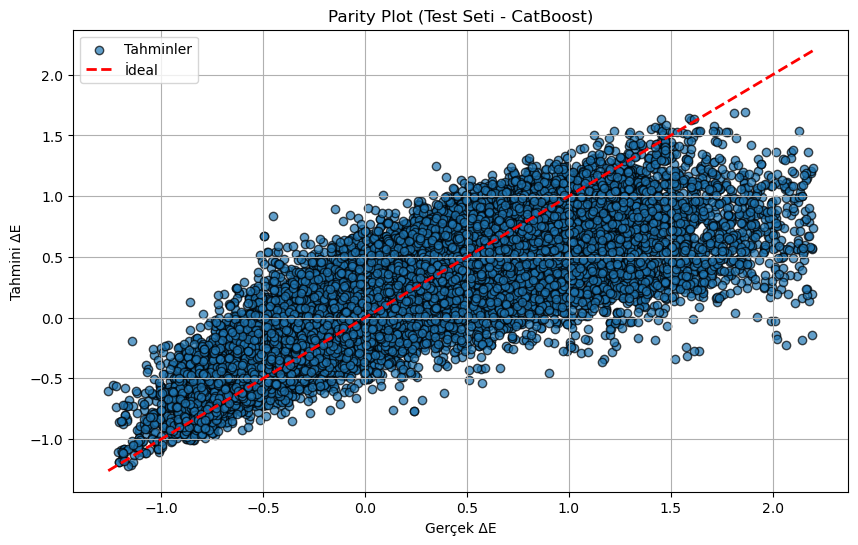

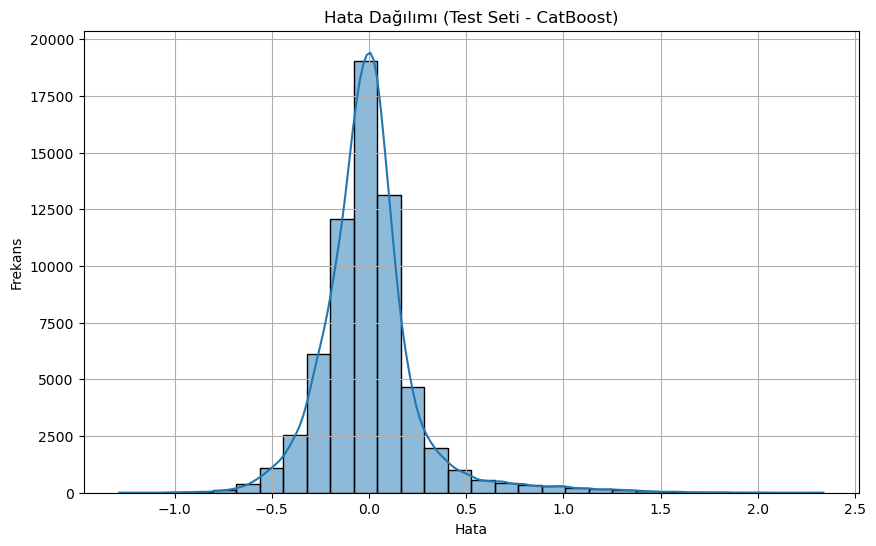

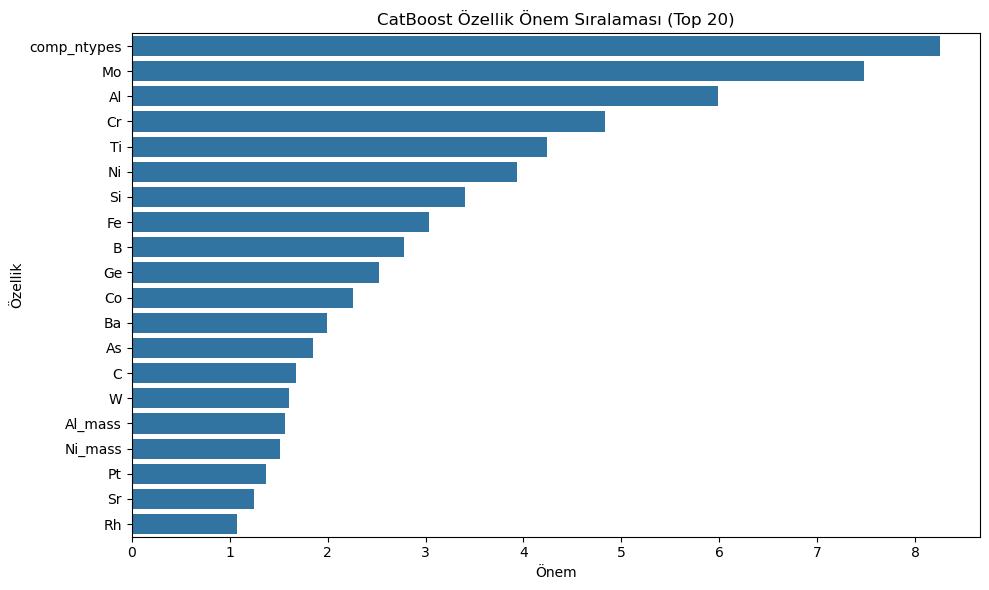

Model 'catboost_delta_e_model.joblib' olarak kaydedildi.
Ölçekleyici 'catboost_scaler.joblib' olarak kaydedildi.
Model özellikleri 'catboost_model_features.joblib' olarak kaydedildi.


In [10]:
# Bu hücre, önceki hücrelerde tanımlanan fonksiyonların bellekte olduğunu varsayar.
# Gerekli importlar ilk hücrede (ID: 62d5a845) zaten yapılmış olmalıdır.

data_file_path = 'veri.csv'
trained_model, trained_scaler, model_feature_cols = None, None, None # Değişkenleri başlangıçta None olarak ayarlayalım

if not os.path.exists(data_file_path):
    print(f"HATA: '{data_file_path}' bulunamadı.")
else:
    # Blok 1: Model Eğitimi, Değerlendirmesi ve Kaydedilmesi
    trained_model, trained_scaler, model_feature_cols = train_evaluate_save_model(
        data_path=data_file_path,
        min_non_zero_frac_filter=0.01,
        variance_threshold_filter=1e-5,
        target_column='delta_e'
    )

# Bu hücrede tanımlanan trained_model, trained_scaler, model_feature_cols 
# bir sonraki hücrede kullanılabilir olacaktır.

In [11]:
# Bu hücre, bir önceki hücrede tanımlanan trained_model, trained_scaler, 
# ve model_feature_cols değişkenlerini kullanır.

if trained_model and model_feature_cols:
    possible_elements = ['Fe', 'Ni', 'Al', 'Cr', 'Co', 'Si', 'C', 'Mo', 'W', 'V']
    # Sadece modelin bildiği özellikler (elementler) arasından arama yapılacakları seç
    elements_for_search = [elem for elem in possible_elements if elem in model_feature_cols]

    if elements_for_search:
        print(f"\nBlok 2 için elementler: {elements_for_search}")
        fixed_s_features = {}
        if 'comp_ntypes' in model_feature_cols: # Eğer 'comp_ntypes' bir özellikse
            fixed_s_features['comp_ntypes'] = len(elements_for_search)
        print(f"Blok 2 için sabit özellikler: {fixed_s_features}")

        # Blok 2: Rastgele DeltaE Arama
        min_delta_e_val_random, best_comp_details_random = find_min_delta_e_random(
            model=trained_model,
            elements_to_vary=elements_for_search,
            all_feature_cols=model_feature_cols,
            scaler=trained_scaler,
            n_iter=1000, # Orijinal notebook'taki değer
            min_frac=0.02,
            fixed_features=fixed_s_features
        )
        # İsteğe bağlı olarak bu blokta bulunan en iyi sonucu yazdırabilirsiniz
        # if best_comp_details_random:
        #     print(f"\nBlok 2 Sonucu: En düşük ΔE (Rastgele Arama): {min_delta_e_val_random:.4f}")
        #     print(f"Blok 2 Kompozisyon (Rastgele Arama): {best_comp_details_random}")
        # else:
        #     print("\nBlok 2: Rastgele arama sonucu uygun kompozisyon bulunamadı.")
    else:
        print("\nBlok 2: Aranacak element model özelliklerinde bulunamadığından çalıştırılamadı.")
elif not os.path.exists(data_file_path):
    print(f"HATA: '{data_file_path}' bulunamadığından Blok 2 çalıştırılamadı.")
else:
    print("\nModel eğitilemedi veya özellikler bulunamadı, Blok 2 çalıştırılamıyor.")


Blok 2 için elementler: ['Fe', 'Ni', 'Al', 'Cr', 'Co', 'Si', 'C', 'Mo', 'W', 'V']
Blok 2 için sabit özellikler: {'comp_ntypes': 10}

--- Blok 2: Rastgele ΔE Arama (CatBoost) ---


C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future v

İt 100/1000 - En düşük ΔE: -0.4936


C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future v

İt 200/1000 - En düşük ΔE: -0.4936


...

C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future v

İt 900/1000 - En düşük ΔE: -0.4936


C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future v

İt 1000/1000 - En düşük ΔE: -0.4936

Arama tamamlandı. En düşük ΔE: -0.4936
Kompozisyon: {'Fe': 0.02974279332839363, 'Ni': 0.1169086029573707, 'Al': 0.0925232161529686, 'Cr': 0.026670461626892787, 'Co': 0.1480817444148913, 'Si': 0.3342509330907715, 'C': 0.0770851765788312, 'Mo': 0.08537587443517201, 'W': 0.02676207176961516, 'V': 0.06259912564509311, 'comp_ntypes': 10}


C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)
C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\2269455771.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future v

In [12]:
# Bu hücre, 4. hücrede tanımlanan trained_model, trained_scaler, 
# ve model_feature_cols değişkenlerini kullanır.

if trained_model and model_feature_cols:
    specific_comp_elements_only = {'Fe': 0.5, 'Al': 0.3, 'Si': 0.2}
    
    # Spesifik kompozisyondaki geçerli (modelin bildiği) elementleri belirle
    valid_elements_in_specific_comp = {
        k: v for k, v in specific_comp_elements_only.items() if k in model_feature_cols
    }
    
    # Tahmin için kullanılacak kompozisyon sözlüğünü oluştur
    composition_for_prediction = valid_elements_in_specific_comp.copy()
    if 'comp_ntypes' in model_feature_cols: # Eğer 'comp_ntypes' modelin kullandığı bir özellikse
        # comp_ntypes değerini, kompozisyondaki geçerli element sayısına göre ayarla
        composition_for_prediction['comp_ntypes'] = len(valid_elements_in_specific_comp)
        
    print(f"\nBlok 3 için kullanılacak kompozisyon: {composition_for_prediction}")

    if valid_elements_in_specific_comp: # Eğer tahmin yapılacak en az bir geçerli element varsa
        # Blok 3: Spesifik DeltaE Tahmini
        predicted_delta_e_specific = predict_delta_e_specific(
            composition_dict=composition_for_prediction,
            model=trained_model,
            all_feature_cols=model_feature_cols,
            scaler=trained_scaler
        )
        # İsteğe bağlı olarak bu blokta bulunan tahmini yazdırabilirsiniz
        # if predicted_delta_e_specific is not None:
        #     print(f"\nBlok 3 Sonucu: Tahmini ΔE (Spesifik Kompozisyon): {predicted_delta_e_specific:.4f}")
    else:
        print("\nBlok 3: Spesifik kompozisyonda modelin bildiği bir element bulunmadığından tahmin yapılamadı.")

elif not os.path.exists(data_file_path):
    print(f"HATA: '{data_file_path}' bulunamadığından Blok 3 çalıştırılamadı.")
else:
    print("\nModel eğitilemedi veya özellikler bulunamadı, Blok 3 çalıştırılamıyor.")

C:\Users\ben00\AppData\Local\Temp\ipykernel_2344\1556737276.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data = pd.DataFrame(columns=all_feature_cols, index=[0]).fillna(0.0)



Blok 3 için kullanılacak kompozisyon: {'Fe': 0.5, 'Al': 0.3, 'Si': 0.2, 'comp_ntypes': 3}

--- Blok 3: Spesifik ΔE Tahmini (CatBoost) ---
Model girdisi: {'Fe': 0.5, 'Al': 0.3, 'Si': 0.2, 'comp_ntypes': 3}

Tahmini ΔE: -0.0156
